## Exploración inicial

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [68]:
orders = pd.read_csv('Orders.csv')
order_details = pd.read_csv('OrderDetails.csv')
results = pd.read_csv('Resultados.csv')

In [69]:
orders.head()

,id_pedido,customer_id,pais,id_businessunit,business_unit,cedis,fecha_pedido,fecha_entrega,status_final,valor_pedido,SubTotal,Total
0,8.839440e+18,8.429210e+18,México,1,Bebidas,3012,16:37.6,00:00.0,Entregado,7,1366.80,1570.94
1,9.056460e+18,3.037320e+18,México,1,Bebidas,3803,21:12.5,00:00.0,Entregado,7,1343.08,1558.01
2,8.986690e+18,3.649870e+18,México,1,Bebidas,3003,35:10.0,00:00.0,Entregado,5,675.00,675.00
3,8.975220e+18,3.451340e+18,México,1,Bebidas,3831,25:26.7,00:00.0,Entregado,5,711.00,721.00
4,8.865940e+18,4.282640e+18,México,1,Bebidas,3808,45:32.7,00:00.0,Entregado,11,3355.17,3924.99


In [70]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68683 entries, 0 to 68682
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_pedido        68683 non-null  float64
 1   customer_id      68683 non-null  float64
 2   pais             68683 non-null  object 
 3   id_businessunit  68683 non-null  int64  
 4   business_unit    68683 non-null  object 
 5   cedis            68683 non-null  object 
 6   fecha_pedido     68683 non-null  object 
 7   fecha_entrega    60423 non-null  object 
 8   status_final     68683 non-null  object 
 9   valor_pedido     68683 non-null  int64  
 10  SubTotal         68683 non-null  float64
 11  Total            68683 non-null  float64
dtypes: float64(4), int64(2), object(6)
memory usage: 6.3+ MB


In [71]:
orders.isnull().sum()   

id_pedido             0
customer_id           0
pais                  0
id_businessunit       0
business_unit         0
cedis                 0
fecha_pedido          0
fecha_entrega      8260
status_final          0
valor_pedido          0
SubTotal              0
Total                 0
dtype: int64

In [72]:
order_details.head()

,id_linea,id_pedido,sku_solicitado,nombre_sku_solicitado,Quantity,Status
0,22363559,9.221880e+18,4.176410e+17,Leche Saborizada Toni Frutilla Poma 200 Ml. ...,12,Entregado
1,22363560,9.221880e+18,8.057490e+18,Leche Saborizada Toni Chocolate Poma 200 Ml. ...,12,Entregado
2,848257,9.221880e+18,4.553460e+18,Telefonía Móvil Claro Tarjeta Paquete $5.15 ...,6,Registrado
3,848258,9.221880e+18,6.085400e+18,TARJETA PAQUETE $3,3,Registrado
4,848259,9.221880e+18,6.629430e+18,Telefonía Móvil Claro Tarjeta Paquete $1.05 ...,30,Registrado


## Exploración Orders

pais
México       46752
Ecuador      13936
Perú          5418
Argentina     2577
Name: count, dtype: int64


Text(0.5, 1.0, 'Cantidad de órdenes por país')

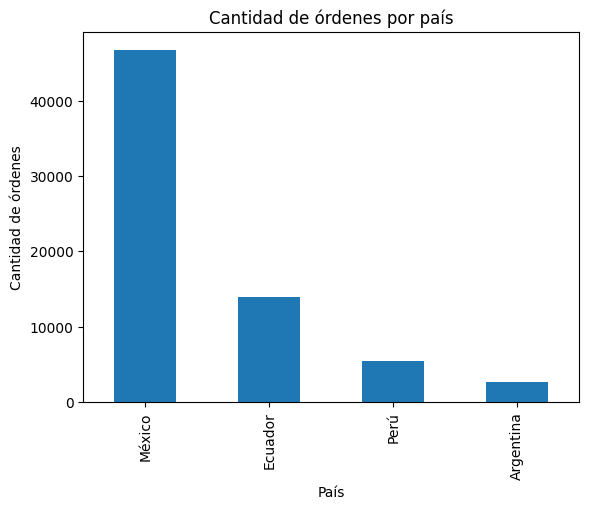

In [73]:
# Count per país y grafica
print(orders['pais'].value_counts())

# Grafica de barras
plot = orders['pais'].value_counts().plot(kind='bar')
plot.set_xlabel('País')
plot.set_ylabel('Cantidad de órdenes')
plot.set_title('Cantidad de órdenes por país')

In [74]:
# Count different status
print(orders['status_final'].value_counts())

status_final
Entregado     60423
Registrado     8145
Rechazado       106
Cancelado         9
Name: count, dtype: int64


In [75]:
# id business unit
print(orders['id_businessunit'].value_counts())

id_businessunit
1     46750
5      9173
3      5418
8      4551
6      2577
19      107
12      105
2         2
Name: count, dtype: int64


In [76]:
# cedis
print(orders['cedis'].value_counts())

cedis
3501    2238
33      2098
3804    2092
3810    2087
3103    2047
        ... 
76         1
C1         1
44         1
AA         1
JE         1
Name: count, Length: 178, dtype: int64


In [77]:
print(results['id_businessunit'].value_counts())

id_businessunit
1     3046
5      209
8      172
19       4
12       3
Name: count, dtype: int64


In [78]:
# group by business unit for id_businessunit
print(orders.groupby('business_unit').size())

business_unit
Bebidas            63918
Helados              107
Lacteos             4551
Multicategorias      105
Papitas                2
dtype: int64


In [79]:
print(orders.groupby(['business_unit', 'id_businessunit']).size())

business_unit    id_businessunit
Bebidas          1                  46750
                 3                   5418
                 5                   9173
                 6                   2577
Helados          19                   107
Lacteos          8                   4551
Multicategorias  12                   105
Papitas          2                      2
dtype: int64


In [93]:
# por pais, que business unit tinee
print(orders.groupby(['pais', 'business_unit']).size())

pais       business_unit  
Argentina  Bebidas             2577
Ecuador    Bebidas             9173
           Helados              107
           Lacteos             4551
           Multicategorias      105
México     Bebidas            46750
           Papitas                2
Perú       Bebidas             5418
dtype: int64


In [80]:
# group by  id_pedido
orders.id_pedido.nunique()


# Vemos que id_pedido es menor al total de registros

32485

In [81]:
orders.id_pedido.unique()

array([8.83944e+18, 9.05646e+18, 8.98669e+18, ..., 8.94808e+18,
       8.85380e+18, 9.10183e+18])

In [82]:
orders[orders['id_pedido']==8.83944e+18]


,id_pedido,customer_id,pais,id_businessunit,business_unit,cedis,fecha_pedido,fecha_entrega,status_final,valor_pedido,SubTotal,Total
0,8.839440e+18,8.429210e+18,México,1,Bebidas,3012,16:37.6,00:00.0,Entregado,7,1366.8,1570.94
8575,8.839440e+18,3.666380e+18,México,1,Bebidas,3501,35:46.0,00:00.0,Entregado,14,2590.3,2982.54
59269,8.839440e+18,4.329320e+18,Perú,3,Bebidas,I1,25:47.9,NaN,Registrado,5,0.0,0.00


In [83]:
# show when id_pedido is duplicated
repetidos = orders[orders["id_pedido"].duplicated(keep=False)]
repetidos.sort_values("id_pedido")

,id_pedido,customer_id,pais,id_businessunit,business_unit,cedis,fecha_pedido,fecha_entrega,status_final,valor_pedido,SubTotal,Total
38098,8.830210e+18,7.360760e+18,México,1,Bebidas,3001,36:22.5,00:00.0,Entregado,43,847.92,871.74
53368,8.830210e+18,3.994370e+18,Argentina,6,Bebidas,11,42:43.0,NaN,Registrado,7,0.00,0.00
21143,8.830240e+18,3.621240e+18,México,1,Bebidas,3804,04:00.7,00:00.0,Entregado,21,4055.26,4676.97
21154,8.830240e+18,9.039370e+18,Ecuador,12,Multicategorias,55,49:29.7,NaN,Registrado,22,0.00,0.00
64758,8.830240e+18,3.996010e+18,México,1,Bebidas,3810,34:10.3,00:00.0,Entregado,7,1254.74,1415.99
...,...,...,...,...,...,...,...,...,...,...,...,...
47933,9.223290e+18,1.674170e+18,Ecuador,8,Lacteos,19,55:24.0,00:00.0,Entregado,42,30.48,33.12
28451,9.223310e+18,6.366180e+18,México,1,Bebidas,3408,34:03.2,00:00.0,Entregado,22,5879.12,6410.65
12865,9.223310e+18,6.289220e+18,México,1,Bebidas,3001,07:19.5,00:00.0,Entregado,13,2790.93,3237.48
5038,9.223360e+18,4.745790e+18,México,1,Bebidas,3206,56:31.4,00:00.0,Entregado,12,3330.98,3863.99


In [84]:
conteo = orders["id_pedido"].value_counts()

conteo_repetidos = conteo[conteo > 1]

print(conteo_repetidos)

id_pedido
9.036680e+18    10
8.974860e+18    10
8.881930e+18     9
9.065780e+18     9
8.917620e+18     9
                ..
8.861230e+18     2
9.070310e+18     2
8.848490e+18     2
9.166210e+18     2
8.980180e+18     2
Name: count, Length: 20551, dtype: int64


In [85]:
reps_pedidos =orders[orders["id_pedido"] == 9.036680e+18]
reps_pedidos.to_csv("pedidos_repetidos.csv", index=False)

In [86]:
id_cust_pedidos = orders.groupby('id_pedido')['customer_id'].nunique()
id_cust_pedidos

id_pedido
8.830190e+18    1
8.830200e+18    1
8.830210e+18    2
8.830220e+18    1
8.830230e+18    1
               ..
9.223310e+18    2
9.223320e+18    1
9.223340e+18    1
9.223360e+18    2
9.223370e+18    1
Name: customer_id, Length: 32485, dtype: int64

In [87]:
orders['id_unique'] = orders['id_pedido'].astype(str) + '_' + orders['customer_id'].astype(str)

In [88]:
orders['id_unique'].value_counts()

id_unique
8.83944e+18_8.42921e+18    1
9.06747e+18_4.99168e+18    1
8.84042e+18_1.19e+18       1
8.96569e+18_3.91606e+18    1
9.09929e+18_7.90041e+18    1
                          ..
9.05961e+18_5.09051e+18    1
9.14123e+18_4.18871e+18    1
9.05902e+18_1.73374e+18    1
8.90288e+18_6.79277e+18    1
8.96618e+18_9.00232e+18    1
Name: count, Length: 68683, dtype: int64

In [89]:
orders

,id_pedido,customer_id,pais,id_businessunit,business_unit,cedis,fecha_pedido,fecha_entrega,status_final,valor_pedido,SubTotal,Total,id_unique
0,8.839440e+18,8.429210e+18,México,1,Bebidas,3012,16:37.6,00:00.0,Entregado,7,1366.80,1570.94,8.83944e+18_8.42921e+18
1,9.056460e+18,3.037320e+18,México,1,Bebidas,3803,21:12.5,00:00.0,Entregado,7,1343.08,1558.01,9.05646e+18_3.03732e+18
2,8.986690e+18,3.649870e+18,México,1,Bebidas,3003,35:10.0,00:00.0,Entregado,5,675.00,675.00,8.98669e+18_3.64987e+18
3,8.975220e+18,3.451340e+18,México,1,Bebidas,3831,25:26.7,00:00.0,Entregado,5,711.00,721.00,8.97522e+18_3.45134e+18
4,8.865940e+18,4.282640e+18,México,1,Bebidas,3808,45:32.7,00:00.0,Entregado,11,3355.17,3924.99,8.86594e+18_4.28264e+18
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68678,9.178340e+18,3.909340e+17,Perú,3,Bebidas,33,52:18.4,NaN,Registrado,3,0.00,0.00,9.17834e+18_3.90934e+17
68679,9.032850e+18,6.969400e+18,México,1,Bebidas,3309,51:30.2,00:00.0,Entregado,2,50.00,50.00,9.03285e+18_6.9694e+18
68680,9.101830e+18,6.095410e+18,México,1,Bebidas,3806,32:48.8,00:00.0,Entregado,5,1179.73,1383.01,9.10183e+18_6.09541e+18
68681,8.985090e+18,4.101580e+18,Argentina,6,Bebidas,11,26:53.4,NaN,Registrado,9,0.00,0.00,8.98509e+18_4.10158e+18


In [90]:
orders[["fecha_pedido", "fecha_entrega"]] = (
    orders[["fecha_pedido", "fecha_entrega"]]
    .replace("NULL", pd.NA)
)

orders["fecha_pedido"] = pd.to_timedelta(
    "00:" + orders["fecha_pedido"].astype(str),
    errors="coerce"
)

orders["fecha_entrega"] = pd.to_timedelta(
    "00:" + orders["fecha_entrega"].astype(str),
    errors="coerce"
)

In [91]:
orders

,id_pedido,customer_id,pais,id_businessunit,business_unit,cedis,fecha_pedido,fecha_entrega,status_final,valor_pedido,SubTotal,Total,id_unique
0,8.839440e+18,8.429210e+18,México,1,Bebidas,3012,0 days 00:16:37.600000,0 days,Entregado,7,1366.80,1570.94,8.83944e+18_8.42921e+18
1,9.056460e+18,3.037320e+18,México,1,Bebidas,3803,0 days 00:21:12.500000,0 days,Entregado,7,1343.08,1558.01,9.05646e+18_3.03732e+18
2,8.986690e+18,3.649870e+18,México,1,Bebidas,3003,0 days 00:35:10,0 days,Entregado,5,675.00,675.00,8.98669e+18_3.64987e+18
3,8.975220e+18,3.451340e+18,México,1,Bebidas,3831,0 days 00:25:26.700000,0 days,Entregado,5,711.00,721.00,8.97522e+18_3.45134e+18
4,8.865940e+18,4.282640e+18,México,1,Bebidas,3808,0 days 00:45:32.700000,0 days,Entregado,11,3355.17,3924.99,8.86594e+18_4.28264e+18
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68678,9.178340e+18,3.909340e+17,Perú,3,Bebidas,33,0 days 00:52:18.400000,NaT,Registrado,3,0.00,0.00,9.17834e+18_3.90934e+17
68679,9.032850e+18,6.969400e+18,México,1,Bebidas,3309,0 days 00:51:30.200000,0 days,Entregado,2,50.00,50.00,9.03285e+18_6.9694e+18
68680,9.101830e+18,6.095410e+18,México,1,Bebidas,3806,0 days 00:32:48.800000,0 days,Entregado,5,1179.73,1383.01,9.10183e+18_6.09541e+18
68681,8.985090e+18,4.101580e+18,Argentina,6,Bebidas,11,0 days 00:26:53.400000,NaT,Registrado,9,0.00,0.00,8.98509e+18_4.10158e+18
